# Comprensione del dataset

## Setup

In [21]:
!apt-get -qq install -y unrar
!pip -q install requests scipy pymupdf matplotlib

## Cosa offre il repository remoto?

In [22]:
import requests, re

URL = 'https://groups.uni-paderborn.de/kat/BearingDataCenter/'
html = requests.get(URL).text            # scarica la pagina come testo
links = re.findall(r'href="([^"]+)"', html)   # estrae tutti i collegamenti
for link in links:
    print(link)

?C=N;O=D
?C=M;O=A
?C=S;O=A
?C=D;O=A
/kat/
K001.rar
K002.rar
K003.rar
K004.rar
K005.rar
K006.rar
KA01.rar
KA03.rar
KA04.rar
KA05.rar
KA06.rar
KA07.rar
KA08.rar
KA09.rar
KA15.rar
KA16.rar
KA22.rar
KA30.rar
KB23.rar
KB24.rar
KB27.rar
KI01.rar
KI03.rar
KI04.rar
KI05.rar
KI07.rar
KI08.rar
KI14.rar
KI16.rar
KI17.rar
KI18.rar
KI21.rar
readme_versions.txt


contiamo le diverse tipologie

In [37]:
tipi = {}
for link in links:
    if link.endswith('.rar'):
        prefisso = link[:-4].rstrip('0123456789')   # toglie i numeri finali: KA04 -> KA
        tipi[prefisso] = tipi.get(prefisso, 0) + 1
tipi

{'K': 6, 'KA': 12, 'KB': 3, 'KI': 11}

## Quanti file di ogni tipo?

In [23]:
import os
from collections import Counter

Counter(os.path.splitext(link)[1] or 'sconosciuto' for link in links)

Counter({'sconosciuto': 5, '.rar': 32, '.txt': 1})

## Cosa dice il README?

In [24]:
print(requests.get(URL + 'readme_versions.txt').text)

2016-07-13:  update of profile of bearing damage KI03 (correction of mistakes in description of damage geometry)


## Scarichiamo un cuscinetto

In [25]:
bearing = 'K001'
with open(bearing + '.rar', 'wb') as f:
    f.write(requests.get(URL + bearing + '.rar').content)

## Estraiamo l'archivio

In [26]:
import subprocess
os.makedirs(bearing, exist_ok=True)
subprocess.run(['unrar', 'x', '-o+', bearing + '.rar', bearing + '/'])

CompletedProcess(args=['unrar', 'x', '-o+', 'K001.rar', 'K001/'], returncode=0)

## Cosa c'e' dentro l'archivio?

In [27]:
for root, dirs, files in os.walk(bearing):
    for f in sorted(files):
        print(os.path.join(root, f))

K001/K001/K001.pdf
K001/K001/N09_M07_F10_K001_1.mat
K001/K001/N09_M07_F10_K001_10.mat
K001/K001/N09_M07_F10_K001_11.mat
K001/K001/N09_M07_F10_K001_12.mat
K001/K001/N09_M07_F10_K001_13.mat
K001/K001/N09_M07_F10_K001_14.mat
K001/K001/N09_M07_F10_K001_15.mat
K001/K001/N09_M07_F10_K001_16.mat
K001/K001/N09_M07_F10_K001_17.mat
K001/K001/N09_M07_F10_K001_18.mat
K001/K001/N09_M07_F10_K001_19.mat
K001/K001/N09_M07_F10_K001_2.mat
K001/K001/N09_M07_F10_K001_20.mat
K001/K001/N09_M07_F10_K001_3.mat
K001/K001/N09_M07_F10_K001_4.mat
K001/K001/N09_M07_F10_K001_5.mat
K001/K001/N09_M07_F10_K001_6.mat
K001/K001/N09_M07_F10_K001_7.mat
K001/K001/N09_M07_F10_K001_8.mat
K001/K001/N09_M07_F10_K001_9.mat
K001/K001/N15_M01_F10_K001_1.mat
K001/K001/N15_M01_F10_K001_10.mat
K001/K001/N15_M01_F10_K001_11.mat
K001/K001/N15_M01_F10_K001_12.mat
K001/K001/N15_M01_F10_K001_13.mat
K001/K001/N15_M01_F10_K001_14.mat
K001/K001/N15_M01_F10_K001_15.mat
K001/K001/N15_M01_F10_K001_16.mat
K001/K001/N15_M01_F10_K001_17.mat
K001/

## Che tipi di file ci sono nell'archivio?

In [28]:
Counter(os.path.splitext(f)[1] for _, _, files in os.walk(bearing) for f in files)

Counter({'.mat': 80, '.pdf': 2})

## Apriamo un file .mat: cosa contiene?

In [29]:
import glob
from scipy.io import loadmat

mat_files = sorted(glob.glob(os.path.join(bearing, '**', '*.mat'), recursive=True))
file = mat_files[0]
mat = loadmat(file)
key = [k for k in mat if not k.startswith('__')][0]
data = mat[key]
print(os.path.basename(file))
print('variabile:', key)
print('shape:', data.shape)
print('campi:', data.dtype.names)

N09_M07_F10_K001_1.mat
variabile: N09_M07_F10_K001_1
shape: (1, 1)
campi: ('Info', 'X', 'Y', 'Description')


## Cosa c'e' dentro ogni campo?

In [30]:
import numpy as np

for field in data.dtype.names:
    value = data[field][0, 0]
    print(field, '|', type(value))
    if isinstance(value, np.ndarray):
        print('  shape:', value.shape, '| dtype:', value.dtype)
        print('  ', value.flatten()[:20] if value.size > 20 else value)
    else:
        print('  ', value)

Info | <class 'numpy.ndarray'>
  shape: (1, 1) | dtype: [('RevisionMajor', 'O'), ('RevisionMinor', 'O'), ('MeasurementID', 'O')]
   [[(array([[2]], dtype=int32), array([[1]], dtype=int32), array([[22]], dtype=int32))]]
X | <class 'numpy.ndarray'>
  shape: (1, 3) | dtype: [('Name', 'O'), ('Type', 'O'), ('Data', 'O'), ('Unit', 'O'), ('Raster', 'O')]
   [[(array([], dtype='<U1'), array([[4]], dtype=int32), array([[-2.22416314e-04,  2.78020392e-05,  2.77592668e-04, ...,
           3.99938108e+00,  3.99963087e+00,  3.99988067e+00]]), array([], dtype='<U1'), array(['Mech_4kHz'], dtype='<U9'))
  (array([], dtype='<U1'), array([[4]], dtype=int32), array([[-3.42178944e-06,  1.19762630e-05,  2.78020392e-05, ...,
           3.99996878e+00,  3.99998460e+00,  4.00000000e+00]]), array([], dtype='<U1'), array(['HostService'], dtype='<U11'))
  (array([], dtype='<U1'), array([[4]], dtype=int32), array([[0.        , 0.99961419, 1.99922796, 2.99884215, 3.99839689]]), array([], dtype='<U1'), array(['Temp_

## Quali segnali (Y) e quali assi (X), con che frequenza?

In [31]:
mat_s = loadmat(file, simplify_cells=True)[key]
for x in mat_s['X']:
    print('X', x['Raster'], '| campioni:', len(x['Data']))
for y in mat_s['Y']:
    print('Y', y['Name'], '| raster:', y['Raster'], '| campioni:', len(y['Data']))

X Mech_4kHz | campioni: 16008
X HostService | campioni: 256823
X Temp_1Hz | campioni: 5
Y force | raster: Mech_4kHz | campioni: 16008
Y phase_current_1 | raster: HostService | campioni: 256823
Y phase_current_2 | raster: HostService | campioni: 256823
Y speed | raster: Mech_4kHz | campioni: 16008
Y temp_2_bearing_module | raster: Temp_1Hz | campioni: 5
Y torque | raster: Mech_4kHz | campioni: 16008
Y vibration_1 | raster: HostService | campioni: 256823


## I segnali in forma di tabella

In [32]:
import pandas as pd

pd.DataFrame([
    {'segnale': y['Name'], 'raster': y['Raster'], 'campioni': len(y['Data'])}
    for y in mat_s['Y']
])

,segnale,raster,campioni
0,force,Mech_4kHz,16008
1,phase_current_1,HostService,256823
2,phase_current_2,HostService,256823
3,speed,Mech_4kHz,16008
4,temp_2_bearing_module,Temp_1Hz,5
5,torque,Mech_4kHz,16008
6,vibration_1,HostService,256823


## Che aspetto ha un segnale?

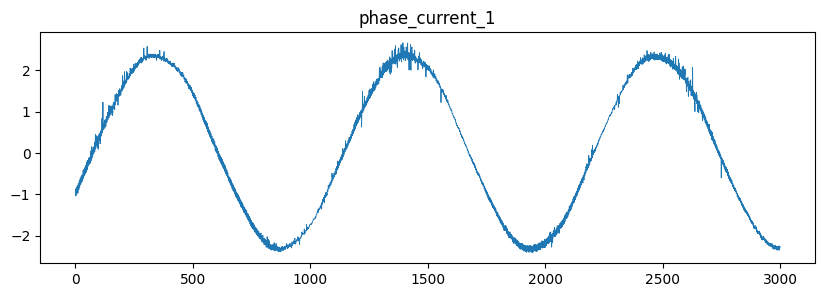

In [33]:
import matplotlib.pyplot as plt

name = 'phase_current_1'   # cambia nome per vedere gli altri segnali
signal = next(y['Data'] for y in mat_s['Y'] if y['Name'] == name)
plt.figure(figsize=(10, 3))
plt.plot(signal[:3000], linewidth=0.6)
plt.title(name)
plt.show()

## Confronto: sano e le tre rotture
Il prefisso del codice indica il tipo: K sano, KA esterno, KI interno, KB entrambe. Prendiamo un cuscinetto per tipo, stesso regime, e guardiamo la corrente.

In [34]:
examples = {
    'sano': 'K001',
    'pista esterna': 'KA04',
    'pista interna': 'KI04',
    'entrambe': 'KB23',
}
for c in examples.values():
    with open(c + '.rar', 'wb') as f:
        f.write(requests.get(URL + c + '.rar').content)
    os.makedirs(c, exist_ok=True)
    subprocess.run(['unrar', 'x', '-o+', c + '.rar', c + '/'])

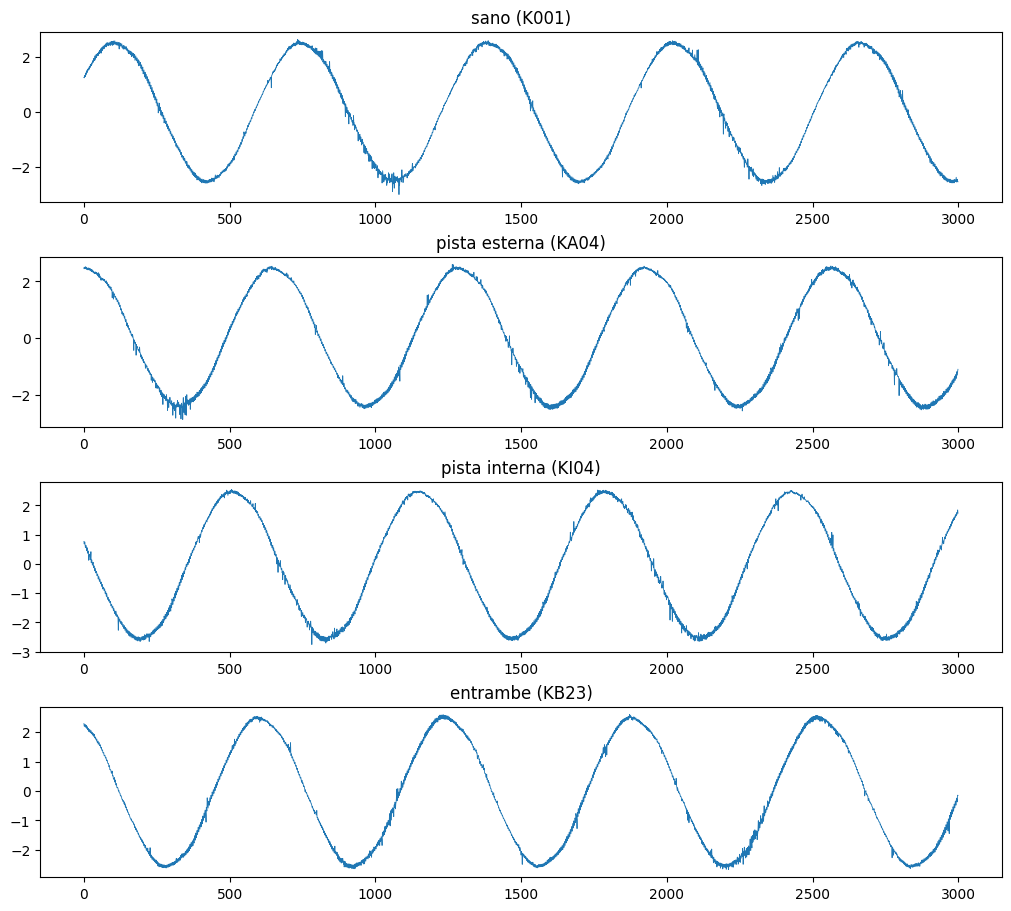

In [35]:
fig, axes = plt.subplots(len(examples), 1, figsize=(10, 9), constrained_layout=True)
for ax, (label, c) in zip(axes, examples.items()):
    f = sorted(glob.glob(os.path.join(c, '**', 'N15_M07_F10_' + c + '_*.mat'), recursive=True))[0]
    m = loadmat(f, simplify_cells=True)
    k = [x for x in m if not x.startswith('__')][0]
    current = next(y['Data'] for y in m[k]['Y'] if y['Name'] == 'phase_current_1')
    ax.plot(current[:3000], linewidth=0.6)
    ax.set_title(label + ' (' + c + ')')
plt.show()

## Cosa dicono i PDF descrittivi?

In [36]:
import fitz
for pdf in sorted(glob.glob(os.path.join(bearing, '**', '*.pdf'), recursive=True)):
    print(os.path.basename(pdf))
    print(fitz.open(pdf)[0].get_text())

K001.pdf
                                                                                         
 
Profile of rolling bearing damage 
Dipl.-Ing. Christian Lessmeier  
Chair of Design and Drive Technology 
 
Pohlweg 47-49, 33098 Paderborn, Germany 
Prof. Dr.-Ing. Detmar Zimmer 
 
Tel.: +49 5251-60-2299 
 
 
Email: christian.lessmeier@upb.de 
 
  
1/1 
 
Profile of rolling bearing damage (Bearing: K001) 
Category 
Unit 
Specification/Value 
General 
info 
 
Bearing Type 
- 
deep groove ball bearing 
Bearing designation 
(dimension series, bore code) 
- 
6203 
Suffix 
- 
- 
Manufacturer specific information 
Geometry 
Diameter of inner raceway 
mm 
n/a 
Diameter of outer raceway 
mm 
n/a 
Pitch circle diameter 
mm 
29.05 
Number of rolling elements 
pc. 
8 
Rolling element diameter 
mm 
6.75 
Length of rolling element 
mm 
6.75 
Nominal pressure angle 
° 
0 
Parameters 
Static load rating 
N 
n/a 
Dynamic load rating 
N 
n/a 
Speed limit 
min-1 
n/a 
 
Manufacturer 
- 
IBU 
Application 